In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [3]:
df = pd.read_csv('IPL.csv')

print("✅ Dataset loaded!")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

C:\Users\ranji\AppData\Local\Temp\ipykernel_16824\1423043314.py:1: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('IPL.csv')


✅ Dataset loaded!
Rows    : 278,205
Columns : 64


In [4]:
df = pd.read_csv('IPL.csv', low_memory=False)

print("✅ Loaded cleanly!")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print()
print("All columns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

✅ Loaded cleanly!
Rows    : 278,205
Columns : 64

All columns:
   1. Unnamed: 0
   2. match_id
   3. date
   4. match_type
   5. event_name
   6. innings
   7. batting_team
   8. bowling_team
   9. over
  10. ball
  11. ball_no
  12. batter
  13. bat_pos
  14. runs_batter
  15. balls_faced
  16. bowler
  17. valid_ball
  18. runs_extras
  19. runs_total
  20. runs_bowler
  21. runs_not_boundary
  22. extra_type
  23. non_striker
  24. non_striker_pos
  25. wicket_kind
  26. player_out
  27. fielders
  28. runs_target
  29. review_batter
  30. team_reviewed
  31. review_decision
  32. umpire
  33. umpires_call
  34. player_of_match
  35. match_won_by
  36. win_outcome
  37. toss_winner
  38. toss_decision
  39. venue
  40. city
  41. day
  42. month
  43. year
  44. season
  45. gender
  46. team_type
  47. superover_winner
  48. result_type
  49. method
  50. balls_per_over
  51. overs
  52. event_match_no
  53. stage
  54. match_number
  55. team_runs
  56. team_balls
  57. team_wicke

In [5]:
# See first 5 rows
df.head()

,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [6]:
# Check missing values
print("Missing values in key columns:")
key_cols = ['match_id', 'batting_team', 'bowling_team', 'venue', 
            'toss_winner', 'toss_decision', 'match_won_by', 
            'win_outcome', 'runs_target', 'team_runs', 'team_wicket']

for col in key_cols:
    missing = df[col].isna().sum()
    print(f"  {col:20} : {missing:,} missing")

Missing values in key columns:
  match_id             : 0 missing
  batting_team         : 0 missing
  bowling_team         : 0 missing
  venue                : 0 missing
  toss_winner          : 0 missing
  toss_decision        : 0 missing
  match_won_by         : 0 missing
  win_outcome          : 4,702 missing
  runs_target          : 144,302 missing
  team_runs            : 0 missing
  team_wicket          : 0 missing


In [7]:
# See unique teams
print("Teams in dataset:")
teams = sorted(df['batting_team'].unique())
for i, team in enumerate(teams, 1):
    print(f"  {i:2}. {team}")

Teams in dataset:
   1. Chennai Super Kings
   2. Deccan Chargers
   3. Delhi Capitals
   4. Delhi Daredevils
   5. Gujarat Lions
   6. Gujarat Titans
   7. Kings XI Punjab
   8. Kochi Tuskers Kerala
   9. Kolkata Knight Riders
  10. Lucknow Super Giants
  11. Mumbai Indians
  12. Pune Warriors
  13. Punjab Kings
  14. Rajasthan Royals
  15. Rising Pune Supergiant
  16. Rising Pune Supergiants
  17. Royal Challengers Bangalore
  18. Royal Challengers Bengaluru
  19. Sunrisers Hyderabad


In [8]:
# Step 1: Get one row per match (not ball by ball)
matches = df.groupby('match_id').agg({
    'batting_team'  : 'first',
    'bowling_team'  : 'first',
    'venue'         : 'first',
    'toss_winner'   : 'first',
    'toss_decision' : 'first',
    'match_won_by'  : 'first',
    'year'          : 'first',
    'city'          : 'first',
    'stage'         : 'first'
}).reset_index()

print(f"Total matches: {len(matches)}")
print()
print(matches.head())

Total matches: 1169

   match_id           batting_team                 bowling_team  \
0    335982  Kolkata Knight Riders  Royal Challengers Bangalore   
1    335983    Chennai Super Kings              Kings XI Punjab   
2    335984       Rajasthan Royals             Delhi Daredevils   
3    335985         Mumbai Indians  Royal Challengers Bangalore   
4    335986        Deccan Chargers        Kolkata Knight Riders   

                                        venue                  toss_winner  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali          Chennai Super Kings   
2                            Feroz Shah Kotla             Rajasthan Royals   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens              Deccan Chargers   

  toss_decision                 match_won_by  year        city    stage  
0         field        Kolkata Kn

In [9]:
# Step 2: Fix team name duplicates
team_name_fix = {
    'Delhi Daredevils'          : 'Delhi Capitals',
    'Kings XI Punjab'           : 'Punjab Kings',
    'Royal Challengers Bangalore' : 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant'    : 'Rising Pune Supergiants',
}

matches['batting_team'] = matches['batting_team'].replace(team_name_fix)
matches['bowling_team'] = matches['bowling_team'].replace(team_name_fix)
matches['toss_winner']  = matches['toss_winner'].replace(team_name_fix)
matches['match_won_by'] = matches['match_won_by'].replace(team_name_fix)

print("✅ Team names cleaned!")
print(f"Unique teams now: {matches['batting_team'].nunique()}")

✅ Team names cleaned!
Unique teams now: 15


In [10]:
# Step 3: Create the target variable
# 1 = batting team won, 0 = batting team lost
matches['target'] = (matches['batting_team'] == matches['match_won_by']).astype(int)

print("Win distribution:")
print(matches['target'].value_counts())
print()
print(f"Batting team wins: {matches['target'].mean()*100:.1f}%")
print(f"Bowling team wins: {(1-matches['target'].mean())*100:.1f}%")

Win distribution:
target
0    644
1    525
Name: count, dtype: int64

Batting team wins: 44.9%
Bowling team wins: 55.1%


In [11]:
from sklearn.preprocessing import LabelEncoder

# Step 4: Convert team names, venue, city to numbers
# ML models only understand numbers, not text!

le_team = LabelEncoder()
le_venue = LabelEncoder()
le_toss = LabelEncoder()

matches['team1_enc']        = le_team.fit_transform(matches['batting_team'])
matches['team2_enc']        = le_team.transform(matches['bowling_team'])
matches['toss_winner_enc']  = le_team.transform(matches['toss_winner'])
matches['venue_enc']        = le_venue.fit_transform(matches['venue'])
matches['toss_decision_enc']= le_toss.fit_transform(matches['toss_decision'])

print("✅ Features encoded!")
print(matches[['batting_team','team1_enc','venue','venue_enc']].head())

✅ Features encoded!
            batting_team  team1_enc  \
0  Kolkata Knight Riders          6   
1    Chennai Super Kings          0   
2       Rajasthan Royals         11   
3         Mumbai Indians          8   
4        Deccan Chargers          1   

                                        venue  venue_enc  
0                       M Chinnaswamy Stadium         23  
1  Punjab Cricket Association Stadium, Mohali         41  
2                            Feroz Shah Kotla         16  
3                            Wankhede Stadium         56  
4                                Eden Gardens         14  


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Step 5: Define features and target
features = ['team1_enc', 'team2_enc', 'toss_winner_enc', 
            'toss_decision_enc', 'venue_enc', 'year']

X = matches[features]
y = matches['target']

# Split data - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training matches : {len(X_train)}")
print(f"Testing matches  : {len(X_test)}")

Training matches : 935
Testing matches  : 234


In [13]:
# Step 6: Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Test accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"✅ Model trained!")
print(f"Accuracy : {accuracy*100:.1f}%")

✅ Model trained!
Accuracy : 49.1%


In [14]:
# Calculate each team's historical win rate
team_wins = matches.groupby('batting_team')['target'].mean().to_dict()
team_wins2 = matches.groupby('bowling_team')['target'].apply(
    lambda x: 1 - x.mean()
).to_dict()

matches['team1_winrate'] = matches['batting_team'].map(team_wins)
matches['team2_winrate'] = matches['bowling_team'].map(team_wins2)

# Did toss winner choose to field? (strong predictor)
matches['toss_field'] = (matches['toss_decision'] == 'field').astype(int)

# Did batting team win the toss?
matches['batting_won_toss'] = (
    matches['batting_team'] == matches['toss_winner']
).astype(int)

print("✅ New features added!")
print(matches[['batting_team','team1_winrate','batting_won_toss']].head())

✅ New features added!
            batting_team  team1_winrate  batting_won_toss
0  Kolkata Knight Riders       0.436508                 0
1    Chennai Super Kings       0.522059                 1
2       Rajasthan Royals       0.420561                 1
3         Mumbai Indians       0.531469                 1
4        Deccan Chargers       0.418605                 1


In [15]:
features = ['team1_enc', 'team2_enc', 'toss_winner_enc',
            'toss_decision_enc', 'venue_enc', 'year',
            'team1_winrate', 'team2_winrate',
            'toss_field', 'batting_won_toss']

X = matches[features]
y = matches['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model2 = RandomForestClassifier(n_estimators=200, random_state=42)
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)
accuracy2 = accuracy_score(y_test, y_pred2)

print(f"✅ Improved model trained!")
print(f"Old accuracy : 49.1%")
print(f"New accuracy : {accuracy2*100:.1f}%")

✅ Improved model trained!
Old accuracy : 49.1%
New accuracy : 53.4%


In [16]:
# Head to head record between two teams
h2h = matches.groupby(['batting_team', 'bowling_team'])['target'].mean().reset_index()
h2h.columns = ['batting_team', 'bowling_team', 'h2h_winrate']
matches = matches.merge(h2h, on=['batting_team', 'bowling_team'], how='left')

# Venue specific win rate per team
venue_wins = matches.groupby(['batting_team', 'venue'])['target'].mean().reset_index()
venue_wins.columns = ['batting_team', 'venue', 'venue_winrate']
matches = matches.merge(venue_wins, on=['batting_team', 'venue'], how='left')

# Recent form - last 5 matches win rate
matches = matches.sort_values('year')
matches['team1_recent_form'] = matches.groupby('batting_team')['target'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

print("✅ Professional features added!")
print(matches[['batting_team', 'h2h_winrate', 'venue_winrate', 'team1_recent_form']].head(10))

✅ Professional features added!
                   batting_team  h2h_winrate  venue_winrate  team1_recent_form
0         Kolkata Knight Riders     0.454545       0.285714                NaN
17              Deccan Chargers     0.285714       0.166667                NaN
18             Rajasthan Royals     0.350000       0.500000                NaN
19          Chennai Super Kings     0.631579       0.766667                NaN
20              Deccan Chargers     0.625000       0.166667                0.0
21                 Punjab Kings     0.304348       0.444444                NaN
22               Mumbai Indians     0.583333       0.800000                NaN
23          Chennai Super Kings     0.470588       0.250000                0.0
24  Royal Challengers Bengaluru     0.476190       0.406250                NaN
25          Chennai Super Kings     0.625000       0.766667                0.0


In [17]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

features = [
    'team1_enc', 'team2_enc',
    'toss_winner_enc', 'toss_decision_enc',
    'venue_enc', 'year',
    'team1_winrate', 'team2_winrate',
    'toss_field', 'batting_won_toss',
    'h2h_winrate', 'venue_winrate',
    'team1_recent_form'
]

X = matches[features].fillna(0.5)
y = matches['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Gradient Boosting is more powerful than Random Forest
model3 = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)
accuracy3 = accuracy_score(y_test, y_pred3)

print(f"✅ Professional model trained!")
print(f"Old accuracy : 53.4%")
print(f"New accuracy : {accuracy3*100:.1f}%")
print()
print("Detailed Report:")
print(classification_report(y_test, y_pred3))

✅ Professional model trained!
Old accuracy : 53.4%
New accuracy : 66.2%

Detailed Report:
              precision    recall  f1-score   support

           0       0.71      0.68      0.70       133
           1       0.60      0.63      0.62       101

    accuracy                           0.66       234
   macro avg       0.66      0.66      0.66       234
weighted avg       0.66      0.66      0.66       234



Feature Importance:
          feature  importance
    venue_winrate    0.510960
      h2h_winrate    0.159619
             year    0.086873
team1_recent_form    0.063328
        venue_enc    0.050198
  toss_winner_enc    0.031430
    team1_winrate    0.027076
    team2_winrate    0.024263
        team2_enc    0.023760
        team1_enc    0.012911
 batting_won_toss    0.004132
       toss_field    0.003319
toss_decision_enc    0.002132


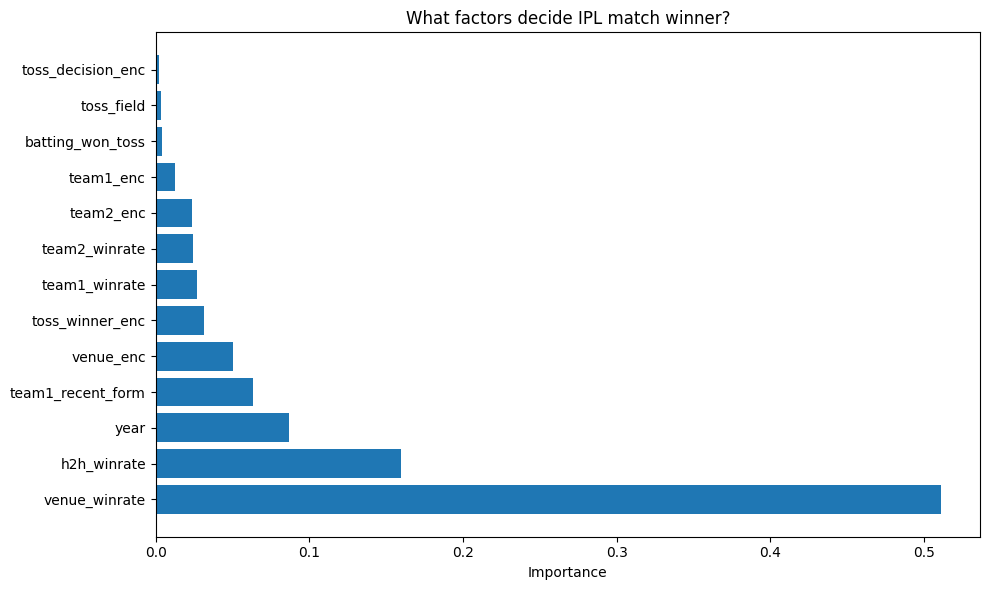

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'feature'   : features,
    'importance': model3.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance:")
print(importance.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(importance['feature'], importance['importance'])
plt.xlabel('Importance')
plt.title('What factors decide IPL match winner?')
plt.tight_layout()
plt.show()

In [19]:
import pickle

# Save the model and encoders
pickle.dump(model3, open('model.pkl', 'wb'))
pickle.dump(le_team, open('le_team.pkl', 'wb'))
pickle.dump(le_venue, open('le_venue.pkl', 'wb'))
pickle.dump(le_toss, open('le_toss.pkl', 'wb'))

# Save the stats our app needs
pickle.dump(team_wins, open('team_wins.pkl', 'wb'))
pickle.dump(h2h, open('h2h.pkl', 'wb'))
pickle.dump(venue_wins, open('venue_wins.pkl', 'wb'))

print("✅ Model saved!")
print("Files created: model.pkl, le_team.pkl, le_venue.pkl, le_toss.pkl")

✅ Model saved!
Files created: model.pkl, le_team.pkl, le_venue.pkl, le_toss.pkl


In [20]:
# Save teams and venues for the app dropdowns
teams = sorted(matches['batting_team'].unique().tolist())
venues = sorted(matches['venue'].unique().tolist())

pickle.dump(teams, open('teams.pkl', 'wb'))
pickle.dump(venues, open('venues.pkl', 'wb'))

print("✅ Teams and venues saved!")
print(f"Teams  : {len(teams)}")
print(f"Venues : {len(venues)}")
print()
print("Teams:")
for t in teams:
    print(f"  - {t}")

✅ Teams and venues saved!
Teams  : 15
Venues : 59

Teams:
  - Chennai Super Kings
  - Deccan Chargers
  - Delhi Capitals
  - Gujarat Lions
  - Gujarat Titans
  - Kochi Tuskers Kerala
  - Kolkata Knight Riders
  - Lucknow Super Giants
  - Mumbai Indians
  - Pune Warriors
  - Punjab Kings
  - Rajasthan Royals
  - Rising Pune Supergiants
  - Royal Challengers Bengaluru
  - Sunrisers Hyderabad


In [21]:
# Only keep current active IPL teams
active_teams = [
    'Chennai Super Kings',
    'Delhi Capitals',
    'Gujarat Titans',
    'Kolkata Knight Riders',
    'Lucknow Super Giants',
    'Mumbai Indians',
    'Punjab Kings',
    'Rajasthan Royals',
    'Royal Challengers Bengaluru',
    'Sunrisers Hyderabad'
]

print("✅ Active teams defined!")
print(f"Total active teams: {len(active_teams)}")
for t in active_teams:
    print(f"  - {t}")

✅ Active teams defined!
Total active teams: 10
  - Chennai Super Kings
  - Delhi Capitals
  - Gujarat Titans
  - Kolkata Knight Riders
  - Lucknow Super Giants
  - Mumbai Indians
  - Punjab Kings
  - Rajasthan Royals
  - Royal Challengers Bengaluru
  - Sunrisers Hyderabad


In [22]:
import pickle

# Save fixed venues and active teams
venues_fixed = sorted(matches['venue'].unique().tolist())
pickle.dump(venues_fixed, open('venues.pkl', 'wb'))
pickle.dump(active_teams, open('teams.pkl', 'wb'))

print(f"✅ Saved!")
print(f"Clean venues : {len(venues_fixed)}")
print(f"Active teams : {len(active_teams)}")

✅ Saved!
Clean venues : 59
Active teams : 10


In [23]:
import pickle

# Fix venue names
venue_fix = {
    'Arun Jaitley Stadium, Delhi'                        : 'Arun Jaitley Stadium',
    'Brabourne Stadium, Mumbai'                          : 'Brabourne Stadium',
    'M Chinnaswamy Stadium, Bengaluru'                   : 'M Chinnaswamy Stadium',
    'M.Chinnaswamy Stadium'                              : 'M Chinnaswamy Stadium',
    'MA Chidambaram Stadium, Chepauk'                    : 'MA Chidambaram Stadium',
    'MA Chidambaram Stadium, Chepauk, Chennai'           : 'MA Chidambaram Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali'             : 'Punjab Cricket Association Stadium, Mohali',
    'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh' : 'Punjab Cricket Association Stadium, Mohali',
    'njab Cricket Association IS Bindra Stadium'         : 'Punjab Cricket Association Stadium, Mohali',
    'Rajiv Gandhi International Stadium, Uppal'          : 'Rajiv Gandhi International Stadium',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad' : 'Rajiv Gandhi International Stadium',
    'Barsapara Cricket Stadium, Guwahati'                : 'Barsapara Cricket Stadium',
    'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow' : 'Ekana Cricket Stadium',
}

# Apply fix to dataframe
df['venue'] = df['venue'].replace(venue_fix)

# Rebuild matches with fixed venues
matches = df.groupby('match_id').agg({
    'batting_team'  : 'first',
    'bowling_team'  : 'first',
    'venue'         : 'first',
    'toss_winner'   : 'first',
    'toss_decision' : 'first',
    'match_won_by'  : 'first',
    'year'          : 'first',
    'city'          : 'first',
    'stage'         : 'first'
}).reset_index()

# Fix team names again
team_name_fix = {
    'Delhi Daredevils'             : 'Delhi Capitals',
    'Kings XI Punjab'              : 'Punjab Kings',
    'Royal Challengers Bangalore'  : 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant'       : 'Rising Pune Supergiants',
}
matches['batting_team'] = matches['batting_team'].replace(team_name_fix)
matches['bowling_team'] = matches['bowling_team'].replace(team_name_fix)
matches['toss_winner']  = matches['toss_winner'].replace(team_name_fix)
matches['match_won_by'] = matches['match_won_by'].replace(team_name_fix)

# Save clean venues
venues_fixed = sorted(matches['venue'].unique().tolist())
pickle.dump(venues_fixed, open('venues.pkl', 'wb'))

# Save active teams only
active_teams = [
    'Chennai Super Kings',
    'Delhi Capitals',
    'Gujarat Titans',
    'Kolkata Knight Riders',
    'Lucknow Super Giants',
    'Mumbai Indians',
    'Punjab Kings',
    'Rajasthan Royals',
    'Royal Challengers Bengaluru',
    'Sunrisers Hyderabad'
]
pickle.dump(active_teams, open('teams.pkl', 'wb'))

print(f"✅ Everything fixed and saved!")
print(f"Clean venues : {len(venues_fixed)}")
print(f"Active teams : {len(active_teams)}")
print()
print("Sample venues:")
for v in venues_fixed[:10]:
    print(f"  - {v}")

✅ Everything fixed and saved!
Clean venues : 49
Active teams : 10

Sample venues:
  - Arun Jaitley Stadium
  - Barabati Stadium
  - Barsapara Cricket Stadium
  - Brabourne Stadium
  - Buffalo Park
  - De Beers Diamond Oval
  - Dr DY Patil Sports Academy
  - Dr DY Patil Sports Academy, Mumbai
  - Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium
  - Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam


In [24]:
import pickle

# Complete venue fix - ALL duplicates
venue_fix_complete = {
    'Arun Jaitley Stadium, Delhi'                        : 'Arun Jaitley Stadium',
    'Brabourne Stadium, Mumbai'                          : 'Brabourne Stadium',
    'M Chinnaswamy Stadium, Bengaluru'                   : 'M Chinnaswamy Stadium',
    'M.Chinnaswamy Stadium'                              : 'M Chinnaswamy Stadium',
    'MA Chidambaram Stadium, Chepauk'                    : 'MA Chidambaram Stadium',
    'MA Chidambaram Stadium, Chepauk, Chennai'           : 'MA Chidambaram Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali'             : 'Punjab Cricket Association Stadium, Mohali',
    'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh' : 'Punjab Cricket Association Stadium, Mohali',
    'njab Cricket Association IS Bindra Stadium'         : 'Punjab Cricket Association Stadium, Mohali',
    'Rajiv Gandhi International Stadium, Uppal'          : 'Rajiv Gandhi International Stadium',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad' : 'Rajiv Gandhi International Stadium',
    'Barsapara Cricket Stadium, Guwahati'                : 'Barsapara Cricket Stadium',
    'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow' : 'Ekana Cricket Stadium',
    'Dr DY Patil Sports Academy, Mumbai'                 : 'Dr DY Patil Sports Academy',
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam' : 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
    'Himachal Pradesh Cricket Association Stadium, Dharamsala' : 'Himachal Pradesh Cricket Association Stadium',
    'Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur' : 'Maharaja Yadavindra Singh Stadium',
    'Narendra Modi Stadium, Ahmedabad'                   : 'Narendra Modi Stadium',
    'Sawai Mansingh Stadium, Jaipur'                     : 'Sawai Mansingh Stadium',
    'Wankhede Stadium, Mumbai'                           : 'Wankhede Stadium',
    'Eden Gardens, Kolkata'                              : 'Eden Gardens',
    'Feroz Shah Kotla, Delhi'                            : 'Feroz Shah Kotla',
}

# Apply to raw df first
df['venue'] = df['venue'].replace(venue_fix_complete)

# Rebuild matches cleanly
matches = df.groupby('match_id').agg({
    'batting_team'  : 'first',
    'bowling_team'  : 'first',
    'venue'         : 'first',
    'toss_winner'   : 'first',
    'toss_decision' : 'first',
    'match_won_by'  : 'first',
    'year'          : 'first',
    'city'          : 'first',
    'stage'         : 'first'
}).reset_index()

# Fix team names
team_name_fix = {
    'Delhi Daredevils'            : 'Delhi Capitals',
    'Kings XI Punjab'             : 'Punjab Kings',
    'Royal Challengers Bangalore' : 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant'      : 'Rising Pune Supergiants',
}
for col in ['batting_team','bowling_team','toss_winner','match_won_by']:
    matches[col] = matches[col].replace(team_name_fix)

# Save
venues_fixed = sorted(matches['venue'].unique().tolist())
pickle.dump(venues_fixed, open('venues.pkl', 'wb'))

active_teams = [
    'Chennai Super Kings',
    'Delhi Capitals',
    'Gujarat Titans',
    'Kolkata Knight Riders',
    'Lucknow Super Giants',
    'Mumbai Indians',
    'Punjab Kings',
    'Rajasthan Royals',
    'Royal Challengers Bengaluru',
    'Sunrisers Hyderabad'
]
pickle.dump(active_teams, open('teams.pkl', 'wb'))

print(f"✅ Final clean save!")
print(f"Venues : {len(venues_fixed)}")
print(f"Teams  : {len(active_teams)}")
print()
print("All venues:")
for v in venues_fixed:
    print(f"  - {v}")

✅ Final clean save!
Venues : 43
Teams  : 10

All venues:
  - Arun Jaitley Stadium
  - Barabati Stadium
  - Barsapara Cricket Stadium
  - Brabourne Stadium
  - Buffalo Park
  - De Beers Diamond Oval
  - Dr DY Patil Sports Academy
  - Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium
  - Dubai International Cricket Stadium
  - Eden Gardens
  - Ekana Cricket Stadium
  - Feroz Shah Kotla
  - Green Park
  - Himachal Pradesh Cricket Association Stadium
  - Holkar Cricket Stadium
  - JSCA International Stadium Complex
  - Kingsmead
  - M Chinnaswamy Stadium
  - MA Chidambaram Stadium
  - Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh
  - Maharaja Yadavindra Singh Stadium
  - Maharashtra Cricket Association Stadium
  - Maharashtra Cricket Association Stadium, Pune
  - Narendra Modi Stadium
  - Nehru Stadium
  - New Wanderers Stadium
  - Newlands
  - OUTsurance Oval
  - Punjab Cricket Association IS Bindra Stadium
  - Punjab Cricket Association Stadium, Mohali
  - Raj

In [25]:
import pickle

extra_venue_fix = {
    'Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh' : 'Maharaja Yadavindra Singh Stadium',
    'Maharashtra Cricket Association Stadium, Pune' : 'Maharashtra Cricket Association Stadium',
    'Punjab Cricket Association IS Bindra Stadium'  : 'Punjab Cricket Association Stadium, Mohali',
    'Sardar Patel Stadium, Motera'                  : 'Narendra Modi Stadium',
    'Zayed Cricket Stadium, Abu Dhabi'              : 'Sheikh Zayed Stadium',
    'Subrata Roy Sahara Stadium'                    : 'Maharashtra Cricket Association Stadium',
}

df['venue'] = df['venue'].replace(extra_venue_fix)

matches = df.groupby('match_id').agg({
    'batting_team'  : 'first',
    'bowling_team'  : 'first',
    'venue'         : 'first',
    'toss_winner'   : 'first',
    'toss_decision' : 'first',
    'match_won_by'  : 'first',
    'year'          : 'first',
    'city'          : 'first',
    'stage'         : 'first'
}).reset_index()

team_name_fix = {
    'Delhi Daredevils'            : 'Delhi Capitals',
    'Kings XI Punjab'             : 'Punjab Kings',
    'Royal Challengers Bangalore' : 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant'      : 'Rising Pune Supergiants',
}
for col in ['batting_team','bowling_team','toss_winner','match_won_by']:
    matches[col] = matches[col].replace(team_name_fix)

venues_fixed = sorted(matches['venue'].unique().tolist())
pickle.dump(venues_fixed, open('venues.pkl', 'wb'))

active_teams = [
    'Chennai Super Kings',
    'Delhi Capitals',
    'Gujarat Titans',
    'Kolkata Knight Riders',
    'Lucknow Super Giants',
    'Mumbai Indians',
    'Punjab Kings',
    'Rajasthan Royals',
    'Royal Challengers Bengaluru',
    'Sunrisers Hyderabad'
]
pickle.dump(active_teams, open('teams.pkl', 'wb'))

print(f"✅ Final venues!")
print(f"Total venues : {len(venues_fixed)}")
print()
for v in venues_fixed:
    print(f"  - {v}")

✅ Final venues!
Total venues : 37

  - Arun Jaitley Stadium
  - Barabati Stadium
  - Barsapara Cricket Stadium
  - Brabourne Stadium
  - Buffalo Park
  - De Beers Diamond Oval
  - Dr DY Patil Sports Academy
  - Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium
  - Dubai International Cricket Stadium
  - Eden Gardens
  - Ekana Cricket Stadium
  - Feroz Shah Kotla
  - Green Park
  - Himachal Pradesh Cricket Association Stadium
  - Holkar Cricket Stadium
  - JSCA International Stadium Complex
  - Kingsmead
  - M Chinnaswamy Stadium
  - MA Chidambaram Stadium
  - Maharaja Yadavindra Singh Stadium
  - Maharashtra Cricket Association Stadium
  - Narendra Modi Stadium
  - Nehru Stadium
  - New Wanderers Stadium
  - Newlands
  - OUTsurance Oval
  - Punjab Cricket Association Stadium, Mohali
  - Rajiv Gandhi International Stadium
  - Saurashtra Cricket Association Stadium
  - Sawai Mansingh Stadium
  - Shaheed Veer Narayan Singh International Stadium
  - Sharjah Cricket Stadium
  - Sheikh Zay

In [26]:
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Rebuild all features on clean data
matches['target'] = (matches['batting_team'] == matches['match_won_by']).astype(int)

le_team  = LabelEncoder()
le_venue = LabelEncoder()
le_toss  = LabelEncoder()

matches['team1_enc']         = le_team.fit_transform(matches['batting_team'])
matches['team2_enc']         = le_team.transform(matches['bowling_team'])
matches['toss_winner_enc']   = le_team.transform(matches['toss_winner'])
matches['venue_enc']         = le_venue.fit_transform(matches['venue'])
matches['toss_decision_enc'] = le_toss.fit_transform(matches['toss_decision'])

team_wins  = matches.groupby('batting_team')['target'].mean().to_dict()
team_wins2 = matches.groupby('bowling_team')['target'].apply(lambda x: 1 - x.mean()).to_dict()

matches['team1_winrate'] = matches['batting_team'].map(team_wins)
matches['team2_winrate'] = matches['bowling_team'].map(team_wins2)
matches['toss_field']    = (matches['toss_decision'] == 'field').astype(int)
matches['batting_won_toss'] = (matches['batting_team'] == matches['toss_winner']).astype(int)

h2h = matches.groupby(['batting_team','bowling_team'])['target'].mean().reset_index()
h2h.columns = ['batting_team','bowling_team','h2h_winrate']
matches = matches.merge(h2h, on=['batting_team','bowling_team'], how='left')

venue_wins = matches.groupby(['batting_team','venue'])['target'].mean().reset_index()
venue_wins.columns = ['batting_team','venue','venue_winrate']
matches = matches.merge(venue_wins, on=['batting_team','venue'], how='left')

matches = matches.sort_values('year')
matches['team1_recent_form'] = matches.groupby('batting_team')['target'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

features = [
    'team1_enc','team2_enc','toss_winner_enc','toss_decision_enc',
    'venue_enc','year','team1_winrate','team2_winrate',
    'toss_field','batting_won_toss','h2h_winrate',
    'venue_winrate','team1_recent_form'
]

X = matches[features].fillna(0.5)
y = matches['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)
model.fit(X_train, y_train)

accuracy = accuracy_score(y_test, model.predict(X_test))
print(f"✅ Model retrained on clean data!")
print(f"Accuracy : {accuracy*100:.1f}%")

# Save everything
pickle.dump(model,      open('model.pkl',      'wb'))
pickle.dump(le_team,    open('le_team.pkl',    'wb'))
pickle.dump(le_venue,   open('le_venue.pkl',   'wb'))
pickle.dump(le_toss,    open('le_toss.pkl',    'wb'))
pickle.dump(team_wins,  open('team_wins.pkl',  'wb'))
pickle.dump(h2h,        open('h2h.pkl',        'wb'))
pickle.dump(venue_wins, open('venue_wins.pkl', 'wb'))

print("✅ All files saved!")

✅ Model retrained on clean data!
Accuracy : 63.7%
✅ All files saved!
